# Loading Data and Library

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import spearmanr, kendalltau
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')

# =============================================================================
# DATA LOADING
# =============================================================================
print("="*70)
print("LOADING DATA")
print("="*70)

mp3_df = pd.read_csv("./data/RL_Data_FullResults_202511281950_mp3.csv")
aac_df = pd.read_csv("./data/RL_Data_FullResults_202512051033_aac.csv")
nc_df = pd.read_csv("./data/RL_Data_FullResults_202512111058_nc.csv")
# Standardize rewards
for df in [mp3_df, aac_df, nc_df]:
    df['reward_std'] = (df['reward'] - df['reward'].mean()) / df['reward'].std()

datasets = {'MP3': mp3_df, 'AAC': aac_df, 'NC': nc_df}
feature_cols = [col for col in mp3_df.columns if col not in ['reward', 'reward_std']]
n_features = len(feature_cols)

print(f"Features: {n_features}")
print(f"Samples per codec: {len(mp3_df)}")

LOADING DATA
Features: 28
Samples per codec: 2700


## remapping the datasets functions for the mapping

In [60]:
track_map = {
    "":  "Vocal",   # no number
    "1": "Drum",
    "2": "Bass",
    "3": "Guitar",
}

param_map = {
    "Hum": "Hum",
    "Hiss": "Hiss",
    "CL": "CL",
    "Thre": "Thre",
    "Ratio": "Ratio",
    "Attk": "Attack",
    "Release": "Release",
}

codec_map = {
    "MP3": "MP3",
    "AAC": "AAC",
    "NC": "EnCodec"
}

import re

def rename_feature(f: str) -> str:
    m = re.fullmatch(r"([A-Za-z]+)(\d*)", f)
    if not m:
        return f

    base, idx = m.group(1), m.group(2)  # idx is "" or "1"/"2"/"3"
    track = track_map.get(idx, f"Track{idx}" if idx else "Track")
    param = param_map.get(base, base)

    return f"{track}_{param}"

# XGModel Preparation

In [4]:
# =============================================================================
# TRAIN XGBOOST MODELS FOR EACH CODEC
# =============================================================================
print("\n" + "="*70)
print("TRAINING XGBOOST MODELS")
print("="*70)


xgb_params = {
    'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1,
    'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0, 'random_state': RANDOM_STATE,
    'n_jobs': -1, 'verbosity': 0, 
}

models = {}
shap_values_dict = {}
X_dict = {}

for codec_name, df in datasets.items():
    X = df[feature_cols].values
    y = df['reward_std'].values
    X_dict[codec_name] = X
    
    model = XGBRegressor(**xgb_params)
    model.fit(X, y)
    models[codec_name] = model
    
    # SHAP values (use sample for speed)
    sample_idx = np.random.choice(len(X), min(1000, len(X)), replace=False)
    X_sample = X[sample_idx]
    explainer = shap.TreeExplainer(model)

    
    shap_values_dict[codec_name] = {
        'values': explainer.shap_values(X_sample),
        'X_sample': X_sample,
        'explainer': explainer
    }
    print(f"{codec_name}: Model trained, SHAP computed")


TRAINING XGBOOST MODELS
MP3: Model trained, SHAP computed
AAC: Model trained, SHAP computed
NC: Model trained, SHAP computed


## EXPLANATORY POWER ^2 RMSE and MAE PER CODEC

In [5]:
import numpy as np
from sklearn.model_selection import cross_validate, RepeatedKFold
from xgboost import XGBRegressor

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

# Use sklearn built-in scorers (most robust across sklearn versions)
scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

print(f"{'Codec':<8} {'R²':<10} {'RMSE':<10} {'MAE':<10} ")
print("-" * 70)

validation_results = {}

for codec_name, df in datasets.items():
    X = df[feature_cols].to_numpy()
    y = df["reward_std"].to_numpy()

    # Optional sanity checks (uncomment if needed)
    # if np.isnan(y).any():
    #     raise ValueError(f"{codec_name}: y contains NaNs (reward_std).")
    # if np.isinf(X).any() or np.isinf(y).any():
    #     raise ValueError(f"{codec_name}: X or y contains inf values.")

    model = XGBRegressor(**xgb_params)

    scores = cross_validate(
        model,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",   # fail loudly instead of returning NaNs
        return_train_score=False
    )

    r2_mean = float(np.mean(scores["test_r2"]))
    rmse_mean = float(-np.mean(scores["test_rmse"]))  # negate back to positive
    mae_mean = float(-np.mean(scores["test_mae"]))    # negate back to positive

    validation_results[codec_name] = {
        "r2": r2_mean,
        "rmse": rmse_mean,
        "mae": mae_mean,
    }

    print(f"{codec_name:<8} {r2_mean:>7.3f}   {rmse_mean:>7.4f}   {mae_mean:>7.4f} ")

print("-" * 70)

Codec    R²         RMSE       MAE        
----------------------------------------------------------------------
MP3        0.947    0.2291    0.1404 
AAC        0.976    0.1526    0.0905 
NC         0.970    0.1703    0.1021 
----------------------------------------------------------------------


## SHAP Importance calculation for the Feature importance

###### "Question: Is feature X significantly MORE important in codec A vs B?"

### Value 

In [6]:
# Calculate mean |SHAP| importance for each codec
importance_matrix = pd.DataFrame(index=feature_cols)

for codec_name in datasets.keys():
    shap_vals = shap_values_dict[codec_name]['values']
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    importance_matrix[codec_name] = mean_abs_shap

# Normalize to sum to 1 for fair comparison
importance_norm = importance_matrix.div(importance_matrix.sum(axis=0), axis=1)

print("Normalised Importance (sum=1 per codec):")
top_features = importance_norm.mean(axis=1).sort_values(ascending=False).head(20).index
print(importance_norm.loc[top_features].round(3).to_string())

Normalised Importance (sum=1 per codec):
          MP3    AAC     NC
Hum1    0.129  0.115  0.173
Hiss    0.107  0.084  0.064
Hiss1   0.061  0.084  0.098
Hum     0.043  0.088  0.097
Hum2    0.062  0.108  0.047
Hiss2   0.079  0.053  0.068
Thre1   0.052  0.071  0.055
Hum3    0.051  0.041  0.083
Ratio1  0.045  0.032  0.074
Thre    0.053  0.054  0.023
Hiss3   0.035  0.050  0.043
CL      0.064  0.029  0.015
Ratio   0.034  0.040  0.033
CL1     0.038  0.029  0.035
CL3     0.026  0.023  0.005
Attk1   0.017  0.011  0.015
Thre2   0.013  0.014  0.012
Attk    0.003  0.028  0.002
Ratio2  0.017  0.002  0.009
Ratio3  0.010  0.010  0.007


### Rank

In [7]:
# Create rank matrix
rank_matrix = importance_matrix.rank(ascending=False)
print("Feature Rankings by Codec:")
print(rank_matrix.loc[top_features].astype(int).to_string())

Feature Rankings by Codec:
        MP3  AAC  NC
Hum1      1    1   1
Hiss      2    4   7
Hiss1     6    5   2
Hum      11    3   3
Hum2      5    2   9
Hiss2     3    8   6
Thre1     8    6   8
Hum3      9   10   4
Ratio1   10   12   5
Thre      7    7  13
Hiss3    13    9  10
CL        4   13  16
Ratio    14   11  12
CL1      12   14  11
CL3      15   16  23
Attk1    17   19  14
Thre2    18   17  17
Attk     26   15  24
Ratio2   16   28  20
Ratio3   21   20  21


### Combing two generate a heatmap

In [64]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Select features
# -----------------------------
top_k = 15

imp = importance_norm.copy()   # normalised |SHAP|
rank = imp.rank(ascending=False).astype(int)

features = (
    imp.mean(axis=1)
    .sort_values(ascending=False)
    .head(top_k)
    .index
)

#imp_plot  = imp.loc[features]
#rank_plot = rank.loc[features]

imp_plot  = imp.loc[features].T
rank_plot = rank.loc[features].T

# rename features using your existing function
# imp_plot.index  = [rename_feature(f) for f in imp_plot.index]
# rank_plot.index = imp_plot.index

imp_plot.columns  = [rename_feature(f) for f in imp_plot.columns]
rank_plot.columns = imp_plot.columns
imp_plot = imp_plot.rename(index=codec_map)
rank_plot = rank_plot.rename(index=codec_map)

annot = np.full(rank_plot.shape, "", dtype=object)

n_annot_cols = 15  # left-most 5 features

for i in range(rank_plot.shape[0]):          # rows = CODECs
    for j in range(min(n_annot_cols, rank_plot.shape[1])):  # first 5 columns
        annot[i, j] = f"{imp_plot.iloc[i, j]:.3f}"

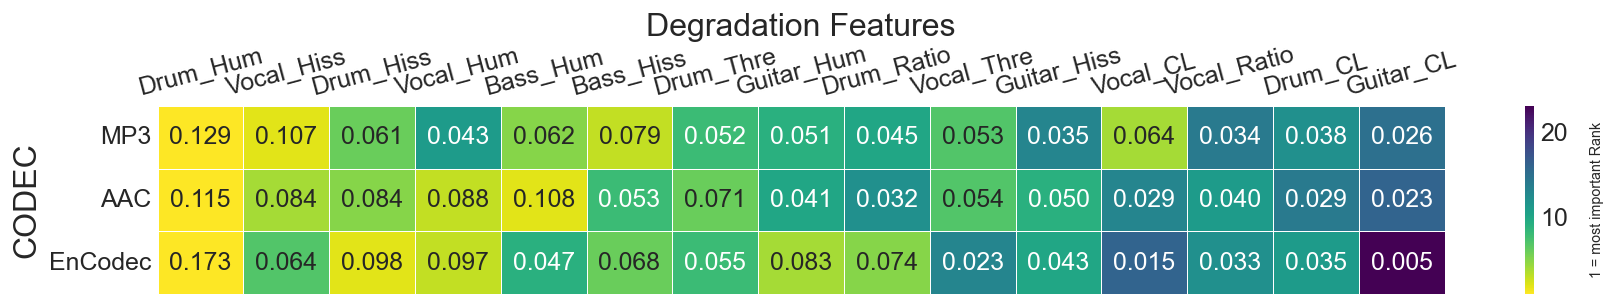

In [89]:
#plt.figure(figsize=(max(4, 0.35 * len(rank_plot)),8), dpi=128)
plt.figure(figsize=(14, 2.5), dpi=128)
# rank is ordinal → sequential colormap
cmap = mpl.cm.get_cmap("viridis_r").copy()
cmap.set_bad("lightgrey")

mask = rank_plot.isna()

ax = sns.heatmap(
    rank_plot,
    mask=mask,
    cmap=cmap,
    annot=annot,
    fmt="",
    linewidths=0.5,
    annot_kws={"fontsize": 14},   # <- cell text size
    linecolor="white",
    cbar_kws={"label": "Rank (1 = most important)"}
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_ylabel("CODEC",fontsize="18")
ax.set_xlabel("Degradation Features", fontsize="18")
ax.tick_params(axis='both', labelsize=14)

# get colorbar
cbar = ax.collections[0].colorbar

# set label fontsize + padding (distance from bar)
cbar.set_label("1 = most important Rank", fontsize=8, labelpad=12)

# set tick fontsize
cbar.ax.tick_params(labelsize=14)

#ax.set_title("Feature Importance Ranking with Normalised |SHAP| Values")
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### ANGLE 2: RANK CONCORDANCE (KENDALL'S W)

In [13]:
# =============================================================================
# ANGLE 2: RANK CONCORDANCE (KENDALL'S W)
# =============================================================================
print("\n" + "="*70)
print("ANGLE 2: RANK CONCORDANCE ANALYSIS")
print("="*70)
print("Question: How much do codecs AGREE on feature rankings overall?")
print("Method: Kendall's W coefficient of concordance\n")

# Create rank matrix
rank_matrix = importance_matrix.rank(ascending=False)
print("Feature Rankings by Codec:")
print(rank_matrix.loc[top_features].astype(int).to_string())

# Calculate Kendall's W
def kendalls_w(ranks_matrix):
    """
    Calculate Kendall's W coefficient of concordance.
    ranks_matrix: DataFrame with features as rows, codecs as columns
    """
    m = ranks_matrix.shape[1]  # number of raters (codecs)
    n = ranks_matrix.shape[0]  # number of items (features)
    
    # Sum of ranks for each item
    R = ranks_matrix.sum(axis=1)
    R_mean = R.mean()
    
    # Sum of squared deviations
    S = ((R - R_mean) ** 2).sum()
    
    # Maximum possible S
    S_max = (m ** 2) * (n ** 3 - n) / 12
    
    W = S / S_max
    
    # Chi-square test for significance
    chi2 = m * (n - 1) * W
    df = n - 1
    p_value = 1 - stats.chi2.cdf(chi2, df)
    
    return W, chi2, df, p_value

W, chi2, df, p_value = kendalls_w(rank_matrix)

print(f"\nKendall's W = {W:.4f}")
print(f"Chi-square = {chi2:.2f}, df = {df}, p = {p_value:.2e}")

print("\nInterpretation:")
if W >= 0.7:
    print(f"  W = {W:.3f} → STRONG agreement across codecs")
elif W >= 0.5:
    print(f"  W = {W:.3f} → MODERATE agreement across codecs")
elif W >= 0.3:
    print(f"  W = {W:.3f} → WEAK agreement across codecs")
else:
    print(f"  W = {W:.3f} → POOR agreement across codecs")

# Pairwise Spearman correlations
print("\n--- Pairwise Rank Correlations (Spearman) ---")
for c1, c2 in codec_pairs:
    rho, p = spearmanr(rank_matrix[c1], rank_matrix[c2])
    print(f"  {c1} vs {c2}: ρ = {rho:.4f}, p = {p:.2e}")


ANGLE 2: RANK CONCORDANCE ANALYSIS
Question: How much do codecs AGREE on feature rankings overall?
Method: Kendall's W coefficient of concordance

Feature Rankings by Codec:
        MP3  AAC  NC
Hum1      1    1   1
Hiss      2    4   7
Hiss1     6    5   2
Hum      11    3   3
Hum2      5    2   9
Hiss2     3    8   6
Thre1     8    6   8
Hum3      9   10   4
Ratio1   10   12   5
Thre      7    7  13
Hiss3    13    9  10
CL        4   13  16
Ratio    14   11  12
CL1      12   14  11
CL3      15   16  23
Attk1    17   19  14
Thre2    18   17  17
Attk     26   15  24
Ratio2   16   28  20
Ratio3   21   20  21

Kendall's W = 0.8728
Chi-square = 70.69, df = 27, p = 8.92e-06

Interpretation:
  W = 0.873 → STRONG agreement across codecs

--- Pairwise Rank Correlations (Spearman) ---
  MP3 vs AAC: ρ = 0.8095, p = 1.82e-07
  MP3 vs NC: ρ = 0.7909, p = 5.46e-07
  AAC vs NC: ρ = 0.8270, p = 5.78e-08


## SHAP Importance calculation for the Feature Comparison

### value

In [90]:
# Statistical test: Bootstrap comparison of importance differences
print("\n--- Bootstrap Test for Importance Differences ---")
print("Testing if importance significantly differs between codecs (α=0.05)\n")

def bootstrap_importance_diff_norm(shap1, shap2, n_boot=1000, eps=1e-12, seed=None):
    """Bootstrap test for difference in normalised mean |SHAP| (sum=1 per codec)."""
    rng = np.random.default_rng(seed)

    def norm_imp(shap):
        imp = np.abs(shap).mean(axis=0)
        s = imp.sum()
        if not np.isfinite(s) or s < eps:
            return np.zeros_like(imp)
        return imp / s

    # observed (normalised) difference
    imp1 = norm_imp(shap1)
    imp2 = norm_imp(shap2)
    observed_diff = imp1 - imp2

    boot_diffs = []
    n1 = len(shap1)
    n2 = len(shap2)

    for _ in range(n_boot):
        idx1 = rng.choice(n1, n1, replace=True)
        idx2 = rng.choice(n2, n2, replace=True)
        boot_imp1 = norm_imp(shap1[idx1])
        boot_imp2 = norm_imp(shap2[idx2])
        boot_diffs.append(boot_imp1 - boot_imp2)

    boot_diffs = np.asarray(boot_diffs)
    ci_lower = np.percentile(boot_diffs, 2.5, axis=0)
    ci_upper = np.percentile(boot_diffs, 97.5, axis=0)

    significant = (ci_lower > 0) | (ci_upper < 0)
    return observed_diff, ci_lower, ci_upper, significant

# Compare each pair
codec_pairs = [('MP3', 'AAC'), ('MP3', 'NC'), ('AAC', 'NC')]
diff_results = {}

for c1, c2 in codec_pairs:
    shap1 = shap_values_dict[c1]['values']
    shap2 = shap_values_dict[c2]['values']
    diff, ci_l, ci_u, sig = bootstrap_importance_diff_norm(shap1, shap2)
    diff_results[(c1, c2)] = {'diff': diff, 'ci_lower': ci_l, 'ci_upper': ci_u, 'significant': sig}
    
    n_sig = sig.sum()
    print(f"{c1} vs {c2}: {n_sig}/{n_features} features significantly different")

# Show top differences
print("\n--- Features with Largest Cross-Codec Differences ---")
diff_summary = pd.DataFrame(index=feature_cols)
for (c1, c2), res in diff_results.items():
    diff_summary[f'{c1}-{c2}'] = res['diff']
    diff_summary[f'{c1}-{c2}_sig'] = res['significant']

diff_summary['max_abs_diff'] = diff_summary[[f'{c1}-{c2}' for c1, c2 in codec_pairs]].abs().max(axis=1)
diff_summary = diff_summary.sort_values('max_abs_diff', ascending=False)
print(diff_summary[['MP3-AAC', 'MP3-NC', 'AAC-NC', 'max_abs_diff']].head(20).round(4).to_string())


--- Bootstrap Test for Importance Differences ---
Testing if importance significantly differs between codecs (α=0.05)

MP3 vs AAC: 25/28 features significantly different
MP3 vs NC: 27/28 features significantly different
AAC vs NC: 28/28 features significantly different

--- Features with Largest Cross-Codec Differences ---
          MP3-AAC  MP3-NC  AAC-NC  max_abs_diff
Hum2      -0.0462  0.0152  0.0614        0.0614
Hum1       0.0142 -0.0432 -0.0574        0.0574
Hum       -0.0450 -0.0535 -0.0085        0.0535
CL         0.0348  0.0495  0.0146        0.0495
Hiss       0.0229  0.0434  0.0205        0.0434
Ratio1     0.0133 -0.0285 -0.0418        0.0418
Hum3       0.0092 -0.0323 -0.0415        0.0415
Hiss1     -0.0224 -0.0365 -0.0141        0.0365
Thre      -0.0004  0.0304  0.0309        0.0309
Attk      -0.0250  0.0014  0.0264        0.0264
Hiss2      0.0256  0.0105 -0.0151        0.0256
CL3        0.0022  0.0210  0.0188        0.0210
Thre1     -0.0188 -0.0028  0.0161        0.0188
Ra